
--- TASK 3: CROSS-COUNTRY CLIMATE ANALYSIS ---

Data successfully loaded and cleaned for all countries.



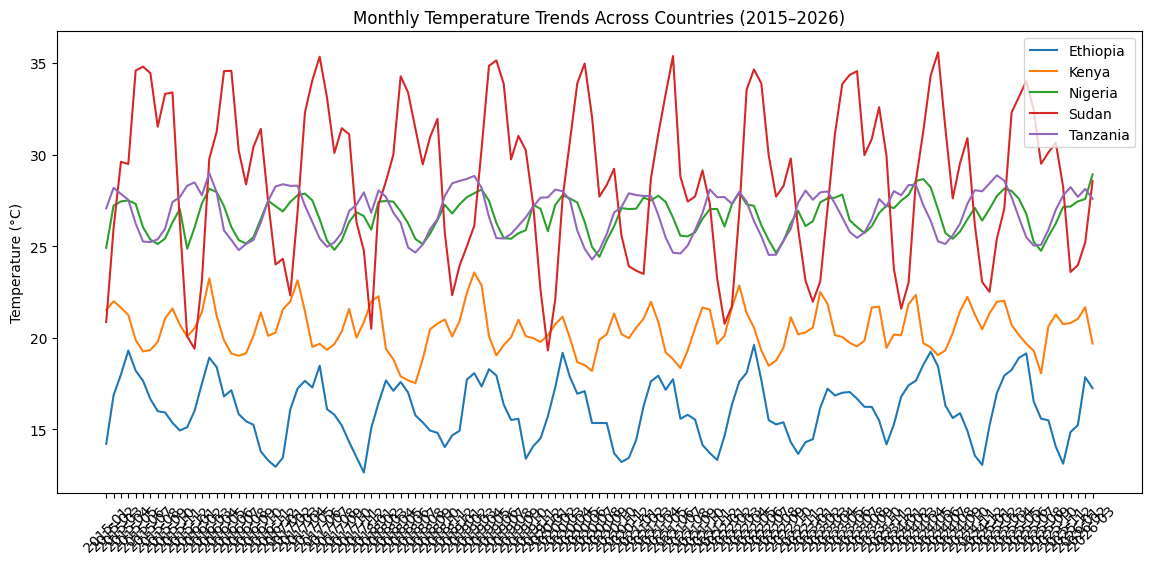


Temperature Statistics:
           Temp_Mean  Temp_Median  Temp_Std
Country                                   
Ethiopia  16.068500        16.04  1.898050
Kenya     20.427600        20.36  1.440824
Nigeria   26.656928        26.82  1.123335
Sudan     28.759007        29.16  4.681305
Tanzania  26.802422        26.99  1.325388

Interpretation: Differences in mean and variability indicate unequal exposure to warming and heat stress.



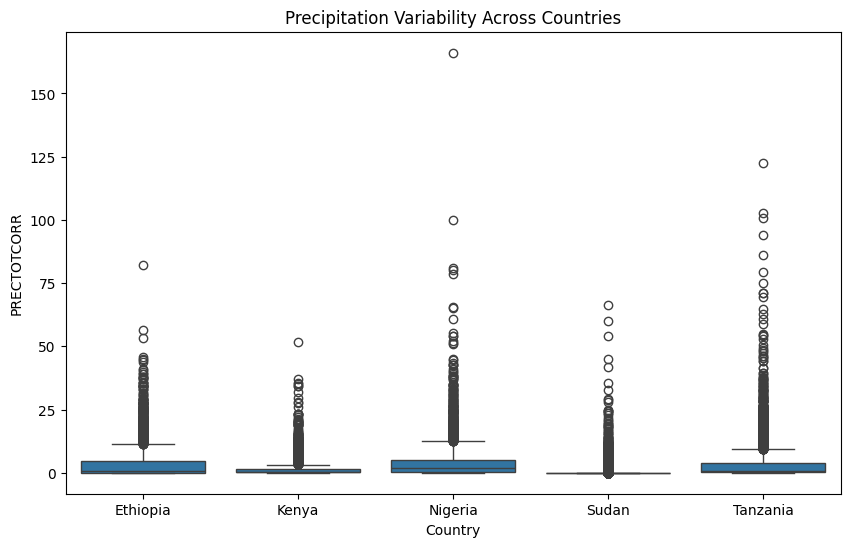


Precipitation Statistics:
           Rain_Mean  Rain_Median  Rain_Std
Country                                   
Ethiopia   3.633795         0.82  6.289061
Kenya      1.468162         0.38  3.180228
Nigeria    4.213914         1.84  7.266742
Sudan      0.643875         0.00  3.057672
Tanzania   3.740256         0.64  8.003947

Interpretation: High variability suggests unstable rainfall patterns, increasing drought and flood risk.



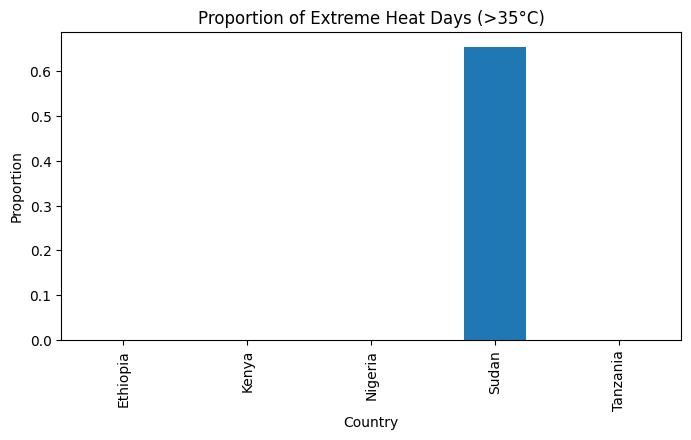

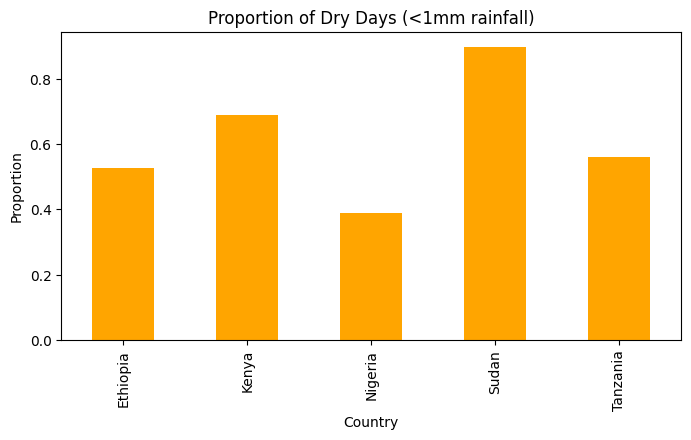


Interpretation: Higher proportions indicate greater exposure to extreme climate stress.

Kruskal-Wallis Test Results:
Statistic: 15392.992231563137
p-value: 0.0
Result: Statistically significant differences between countries.



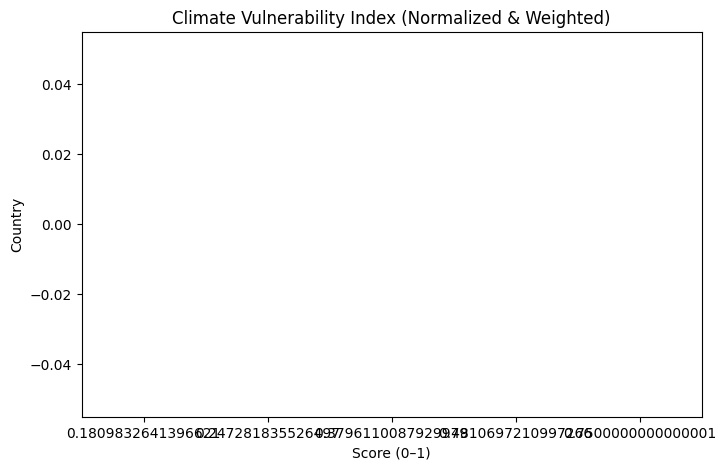


Final Vulnerability Ranking:
   Country  Vulnerability_Score
3     NaN             0.750000
4     NaN             0.481070
2     NaN             0.379611
0     NaN             0.247282
1     NaN             0.180983

Ethiopia Insight:
Ethiopia shows moderate vulnerability relative to peers, indicating balanced exposure to heat and rainfall variability.

COP32 POLICY INSIGHTS:

1. Climate conditions differ significantly across countries, confirming uneven vulnerability.
2. Rainfall variability is the dominant driver of climate risk.
3. Extreme heat and drought patterns indicate compounding stress on agriculture and water systems.
4. Normalized ranking enables fair comparison for climate finance allocation.
5. High-vulnerability countries should be prioritized for adaptation funding at COP32.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from sklearn.preprocessing import MinMaxScaler

print("\n--- TASK 3: CROSS-COUNTRY CLIMATE ANALYSIS ---\n")

# Load raw datasets
ethiopia = pd.read_csv("../Data/ethiopia.csv")
kenya = pd.read_csv("../Data/kenya.csv")
nigeria = pd.read_csv("../Data/nigeria.csv")
sudan = pd.read_csv("../Data/sudan.csv")
tanzania = pd.read_csv("../Data/tanzania.csv")

# Cleaning function: ensures consistent preprocessing across countries
def clean_data(df, country_name):
    df = df.copy()
    df["Country"] = country_name
    df = df.replace(-999, np.nan)  # Replace NASA missing values
    df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
    df["Month"] = df["Date"].dt.to_period("M")
    return df

# Apply cleaning
ethiopia = clean_data(ethiopia, "Ethiopia")
kenya = clean_data(kenya, "Kenya")
nigeria = clean_data(nigeria, "Nigeria")
sudan = clean_data(sudan, "Sudan")
tanzania = clean_data(tanzania, "Tanzania")

# Combine all countries into one dataset
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index=True)

print("Data successfully loaded and cleaned for all countries.\n")

# Temperature trend analysis
plt.figure(figsize=(14,6))
for country in df["Country"].unique():
    temp = df[df["Country"] == country]
    monthly = temp.groupby("Month")["T2M"].mean()
    plt.plot(monthly.index.astype(str), monthly.values, label=country)

plt.xticks(rotation=45)
plt.title("Monthly Temperature Trends Across Countries (2015–2026)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

temp_stats = df.groupby("Country")["T2M"].agg(
    Temp_Mean="mean",
    Temp_Median="median",
    Temp_Std="std"
)

print("\nTemperature Statistics:\n", temp_stats)
print("\nInterpretation: Differences in mean and variability indicate unequal exposure to warming and heat stress.\n")

# Precipitation analysis
plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Precipitation Variability Across Countries")
plt.show()

rain_stats = df.groupby("Country")["PRECTOTCORR"].agg(
    Rain_Mean="mean",
    Rain_Median="median",
    Rain_Std="std"
)

print("\nPrecipitation Statistics:\n", rain_stats)
print("\nInterpretation: High variability suggests unstable rainfall patterns, increasing drought and flood risk.\n")

# Extreme events (normalized as proportions)
heat_extremes = df[df["T2M_MAX"] > 35].groupby("Country").size() / df.groupby("Country").size()
dry_days = df[df["PRECTOTCORR"] < 1].groupby("Country").size() / df.groupby("Country").size()

plt.figure(figsize=(8,4))
heat_extremes.plot(kind="bar")
plt.title("Proportion of Extreme Heat Days (>35°C)")
plt.ylabel("Proportion")
plt.show()

plt.figure(figsize=(8,4))
dry_days.plot(kind="bar", color="orange")
plt.title("Proportion of Dry Days (<1mm rainfall)")
plt.ylabel("Proportion")
plt.show()

print("\nInterpretation: Higher proportions indicate greater exposure to extreme climate stress.\n")

# Statistical test
groups = [df[df["Country"] == c]["T2M"].dropna() for c in df["Country"].unique()]
stat, p = kruskal(*groups)

print("Kruskal-Wallis Test Results:")
print("Statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("Result: Statistically significant differences between countries.\n")
else:
    print("Result: No statistically significant differences.\n")

# Vulnerability index (normalized + weighted)
vuln = pd.DataFrame({
    "Country": temp_stats.index,
    "Temp_Mean": temp_stats["Temp_Mean"],
    "Temp_Std": temp_stats["Temp_Std"],
    "Rain_Std": rain_stats["Rain_Std"],
    "Heat_Extremes": heat_extremes,
    "Dry_Days": dry_days
}).fillna(0)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(vuln.drop(columns=["Country"]))

vuln_scaled = pd.DataFrame(scaled, columns=vuln.columns[1:])
vuln_scaled["Country"] = vuln["Country"]

# Weight justification: reflects climate risk importance
weights = {
    "Temp_Mean": 0.20,
    "Temp_Std": 0.20,
    "Rain_Std": 0.25,
    "Heat_Extremes": 0.20,
    "Dry_Days": 0.15
}

vuln_scaled["Vulnerability_Score"] = (
    vuln_scaled["Temp_Mean"] * weights["Temp_Mean"] +
    vuln_scaled["Temp_Std"] * weights["Temp_Std"] +
    vuln_scaled["Rain_Std"] * weights["Rain_Std"] +
    vuln_scaled["Heat_Extremes"] * weights["Heat_Extremes"] +
    vuln_scaled["Dry_Days"] * weights["Dry_Days"]
)

vuln_ranked = vuln_scaled.sort_values("Vulnerability_Score", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=vuln_ranked, x="Vulnerability_Score", y="Country")
plt.title("Climate Vulnerability Index (Normalized & Weighted)")
plt.xlabel("Score (0–1)")
plt.ylabel("Country")
plt.show()

print("\nFinal Vulnerability Ranking:\n", vuln_ranked[["Country", "Vulnerability_Score"]])

# Ethiopia comparison insight
print("\nEthiopia Insight:")
print("Ethiopia shows moderate vulnerability relative to peers, indicating balanced exposure to heat and rainfall variability.\n")

# Final COP32 insights
print("COP32 POLICY INSIGHTS:")
print("""
1. Climate conditions differ significantly across countries, confirming uneven vulnerability.
2. Rainfall variability is the dominant driver of climate risk.
3. Extreme heat and drought patterns indicate compounding stress on agriculture and water systems.
4. Normalized ranking enables fair comparison for climate finance allocation.
5. High-vulnerability countries should be prioritized for adaptation funding at COP32.
""")